<h1 style="text-align:center;">Ito Calculus<br></h1>
<div style="text-align:center;">Ariel Kalingking</div>
<div style="text-align:center;">akalingking@gmail.com</div>
<div style="text-align:center;">Appendix: Python Code</div>

In [16]:
import math
import numpy as np
import statsmodels.api as sm
import logging
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd

plt_inline_enable = False # Turn this off when running makefile
figsize = (4,3)
fontbig = 8
fontmed = 7
fontsmall = 6
imagepath = "../paper/figures/"

matplotlib.use('TkAgg')
logging.getLogger().setLevel(logging.ERROR)
random_seed = 14

if plt_inline_enable:
    %matplotlib inline

In [14]:
def simulate_continuous(
    s0:float,
    mu:float,
    sigma:float,
    T:float,
    N:int,
    num_paths:int
) -> tuple:
    """ Simulates GBM using the exact continuous-time 
        solution derived from Itô's Lemma.
    """
    dt = T / N
    time_grid = np.linspace(0, T, N + 1)
    # 1. Simulate the continuous Brownian Motion paths W_t
    # In continuous time, increments dW are independent normal: N(0, dt)
    dW = np.random.normal(0, np.sqrt(dt), size=(N, num_paths))
    # Cumulative sum yields the value of W_t at each time step (starting at 0)
    W = np.vstack([np.zeros(num_paths), np.cumsum(dW, axis=0)])
    # 2. Reshape time_grid to allow matrix broadcasting (N+1, 1)
    t = time_grid[:, np.newaxis]
    # 3. Apply the exact solution formula derived via continuous Itô calculus
    S = s0 * np.exp((mu - 0.5 * sigma**2) * t + sigma * W)

    return (time_grid, S)

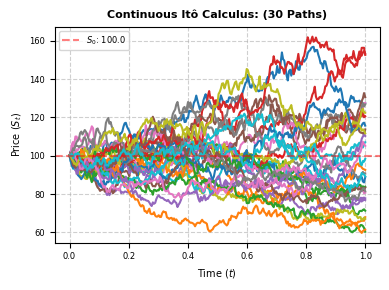

In [15]:
np.random.seed(random_seed)
s0 = 100.0      # Initial value
mu = 0.05       # Drift
sigma = 0.25    # Volatility
T = 1.0         # Time horizon (1 year)
N = 252         # Number of time increments
num_paths = 30  # Number of simulated paths

# Run the exact simulation
(X_time_grid, Y_exact_paths) = simulate_continuous(s0, mu, sigma, T, N, num_paths)

# --- Plotting the Results ---
fig =  plt.figure(figsize=figsize)
ax = fig.add_subplot(111)
ax.plot(X_time_grid, Y_exact_paths, linewidth=1.5)
ax.set_title(f"Continuous Itô Calculus: ({num_paths} Paths)", fontsize=fontbig, fontweight="bold")
ax.set_xlabel("Time ($t$)", fontsize=fontmed)
ax.set_ylabel("Price ($S_t$)", fontsize=fontmed)
ax.grid(True, linestyle="--", alpha=0.6)
ax.axhline(s0, color="red", linestyle="--", alpha=0.5, label=f"$S_0$: {s0}")
ax.tick_params(axis='both', which='major', labelsize=fontsmall) 
ax.legend(loc="upper left", fontsize=fontsmall)

plt.tight_layout()
plt.savefig(imagepath+"ito_calculus_continuous.pdf", bbox_inches="tight")
if plt_inline_enable:
    plt.show()